## Term Paper - Winter Semester 25/26 Submission

#### **Research Topic: Is Attention All You Need in Low-Resource Settings? An empirical study of self attention integrated with BiLSTM vs Transformers for a low resource language; Swahili.**

In [1]:
import numpy as np
import pandas as pd
import re
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForTokenClassification

pd.set_option("display.max_colwidth", None)

/Users/carolmuchemi/Documents/Cayo/MSc/Course Work/WiSe 2526/Maching Learning for Natural Language Understanding/masters_nlp/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
holdout_train = pd.read_csv("Swahili_News_Train.csv")
holdout_test = pd.read_csv("Swahili_News_Test.csv")

print(f"Validate train column names: {holdout_train.columns},\nValidate test column names: {holdout_test.columns}")

Validate train column names: Index(['id', 'content', 'category'], dtype='object'),
Validate test column names: Index(['swahili_id', 'content'], dtype='object')


In [3]:
swahili_news = pd.read_csv("SwahiliNewsClassificationDataset.csv")
swahili_news.head()

,id,content,category
0,SW4670,"Bodi ya Utalii Tanzania (TTB) imesema, itafanya misafara ya kutangaza utalii kwenye miji minne nchini China kati ya Juni 19 hadi Juni 26 mwaka huu.Misafara hiyo itatembelea miji ya Beijing Juni 19, Shanghai Juni 21, Nanjig Juni 24 na Changsha Juni 26.Mwenyekiti wa bodi TTB, Jaji Mstaafu Thomas Mihayo ameyasema hayo kwenye mkutano na waandishi wa habari jijini Dar es Salaam.“Tunafanya jitihada kuhakikisha tunavuna watalii wengi zaidi kutoka China hasa tukizingatia umuhimu wa soko la sekta ya utalii nchini,” amesema Jaji Mihayo.Novemba 2018 TTB ilifanya ziara kwenye miji ya Beijing, Shanghai, Chengdu, Guangzhou na Hong Kong kutangaza vivutio vya utalii sanjari kuzitangaza safari za ndege za Air Tanzania.Ziara hiyo inaelezwa kuzaa matunda ikiwa ni pamoja na watalii zaidi ya 300 kuja nchini Mei mwaka huu kutembelea vivutio vya utalii.",uchumi
1,SW30826,"PENDO FUNDISHA-MBEYA RAIS Dk. John Magufuri, ametangaza kuwafukuza\nkazi wakurugenzi wote wa halmashauri ambao watabainika kukiuka sheria ya\nufutaji wa tozo za ushuru wa mazao. Alisema baada ya kuingia madarakani, Serikali\niliondoa tozo 80, miongoni mwa hizo tozo ushuru wakulima ambao walikuwa\nwakilipa mazao kutoka halmashauri moja kwenda nyingine. Rais Dk. Magufuli, aliyasema hayo juzi alipokuwa\nakiwahutubia wakazi wa Wilaya ya Kyela katika ziara ya kikazi ya siku 10 mkoani\nMbeya. Alisema, sheria ya ufutaji wa tozo hizo\nzilipitishwa na Bunge hivyo hakuna mtu yoyote wa kuitengua na kwamba Mkurugenzi\natakaye itengua atakuwa umevunja sheria na anawajibu wa kufukuzwa kazi. Alisema licha ya kupitishwa kwa sheria hiyo wapo\nbaadhi ya watendaji wameendelea kuwatoza ushuru wananchi kwa kisingizio cha\nkupandisha ukusanyaji wa mapato hilo jambo sitaki kulisikia. “Wapo watendaji\nwanasema kufutwa kwa ushuru kunapunguza mapato, narudia kwa viongozi wote, wakurugenzi,\nwatendaji wote wa halmashauri msiwatoze wananchi ushuru wa mzigo wowote usio\nzidi tani moja,”alisema. Hata hivyo, alitoa wito kwa watendaji kuzingatia\nsheria ya kuwalinda wakulima na ndio maana serikali iliziondoa tozo 80.",kitaifa
2,SW29725,"Mwandishi Wetu -Singida BENKI ya NMB imetoa msaada wa vifaa mbalimbali vyenye thamani ya zaidi ya Sh milioni 200 katika wilaya kadhaa nchini. Misaada iliyotolewa na benki hiyo inayoongoza kwa kutengeneza faida kati ya benki zote zinazofanya biashara humu nchini ndani ya miezi mitano mwaka huu, inahusisha vifaa vya ujenzi, madawati na vifaa vingine vinavyowezesha ukamilishaji wa miradi ya afya,elimu na usalama wa raia. Benki ya NMB imeshatoa msaada wa vifaa vyenye thamani ya zaidi ya Sh milioni 200 kwa mikoa ya Kanda ya Kati. Akifafanua kuhusu misaada hiyo wakati akikabidhi msaada wa madawati na vitanda kwa baadhi ya shule katika Halmashauri ya Wilaya ya Iramba mkoani ingida, Meneja wa Kanda ya Kati wa NMB, Nsolo Mlozi, alibainisha kuwa misaada hiyo ya zaidi ya Sh milioni 200 iliyotolewa imelenga sekta ya elimu, afya na majanga kwa mikoa mitatu ya Kanda ya kati. Akikabidhi msaada wa madawati na vitanda kwa baadhi ya shule za Halmashauri ya Wilaya ya Iramba, MkoaniSingida, katika shule ya Sekondari ya New Kiomboi, Mlozi alisema fedha hizo zilizotolewa na NMB zimetumika kununua madawati, viti vya shule za sekondari,vitanda na vifaa tiba kwenye sekta ya afya. Aidha, alisema lengo la misaada hiyo ni kuunga mkono juhudi za serikali kuwahudumia wananchi kwenye sekta mbalimbali. Pia alisema misaada hiyo imekabidhiwa kwa baadhi ya shule, zahanati, hospitali katika mikoa ya Singida, Dodoma na Manyara. Pia NMB walikabidhi madawati 250 na vitanda 80 vyenye thamani ya zaidi ya Sh milioni 29.5 kwa baadhi ya shule za Wilaya ya Iramba mkoani humo. Katika hatua nyingine, Benki hiyo imevipatia kituo cha Polisi Wilaya ya Kilosa mkoani Morogoro pamoja na shule ya msingi Msowelo mabati 160 yenye thamani ya Sh5 milioni kwa ajili ya kuezekea maboma. NMB iliamua kutoa msaada huo ikiwa ni mpango wa kuzipunguza baadhi ya changamoto kwa taasisi za serikali hapa nchini, Meneja 

In [4]:
holdout_train.head(1)

,id,content,category
0,SW0,"SERIKALI imesema haitakuwa tayari kuona amani na utulivu wa nchi inachezewa huku ikisisitiza uwepo wa umoja kati ya wananchi bila kujali tofauti ya imani, kabila au itikadi yoyote.Hayo yalisemwa na Naibu Waziri wa Mambo ya Ndani ya Nchi, Hamad Yussuf Masauni wakati akifungua semina ya siku mbili iliyofanyika jijini Dar es Salaam ikiwahusisha viongozi wa taasisi za Kiislamu, lengo ikiwa ni kuwakumbusha kuhubiri amani katika sehemu zao.Naibu Waziri amesema mwelekeo na malengo ya Serikali ya Awamu ya Tano ni kukuza maendeleo katika sehemu mbalimbali nchini lengo ikiwa kuinua maisha ya wananchi na nchi kwa ujumla.“Serikali hii imejidhatiti kuhakikisha maendeleo yanakuja kwa kasi na maendeleo hayawezi kuja ikiwa amani na utulivu haupo, sisi kama serikali tutahakikisha tunalinda amani iliyopo ili wananchi wapate kufanya shughuli za kiuchumi bila wasiwasi wowote,” amesema Masauni.Akizungumza wakati wa ufunguzi huo, Shehe wa Mkoa wa Dar es Salaam, Alhaji Alhad Mussa Salum aliihakikishia serikali kutokuwepo kwa mifarakano kati ya taasisi mbalimbali kama ilivyokuwepo awali huku akisisitiza kuendelea kwa umoja huo ili jamii ipate kuendelea.“Sisi kama Bakwata tunaihakikishia serikali uwepo wa umoja na ushirikiano baina ya baraza na taasisi zingine na tofauti zetu hazipelekei kukoseana au kuvunjiana heshima kwahiyo tunaomba serikali iamini uwepo wa maelewano mazuri tu kwa maendeleo ya nchi hii,” amesema Shehe Alhad.Semina hiyo ya siku mbili imejumuisha viongozi wa taasisi 100 huku mada ya Nafasi ya Taasisi za Kiislamu katika Kuleta Umoja na Kuishi kwa Amani itajadiliwa.",Kitaifa


In [5]:
print(
    f"Training set has {swahili_news.shape[0]} rows while validation/developer set has {holdout_train.shape[0]} rows."
    )

Training set has 23268 rows while validation/developer set has 5151 rows.


In [6]:
print(
    f"Categories in training but missing in validation: {set(swahili_news["category"].str.lower().unique()) - set(holdout_train["category"].str.lower().unique())}"
    )

Categories in training but missing in validation: {'afya', 'uchumi'}


In [7]:
print(
    f"Categories in validation but missing in training: {set(holdout_train["category"].str.lower().unique()) - set(swahili_news["category"].str.lower().unique())}"
    )

Categories in validation but missing in training: {'biashara'}


In [8]:
print(
    f"Categories in validation but missing in training: {set(holdout_train["category"].unique()) - set(swahili_news["category"].unique())}"
    )

Categories in validation but missing in training: {'Biashara', 'Burudani', 'Kitaifa', 'Kimataifa'}


In [9]:
print(
    f"Categories is training data: {swahili_news["category"].str.lower().unique()}.\nCategories in validation set: {holdout_train["category"].str.lower().unique()}"
    )

Categories is training data: ['uchumi' 'kitaifa' 'michezo' 'kimataifa' 'burudani' 'afya'].
Categories in validation set: ['kitaifa' 'biashara' 'michezo' 'kimataifa' 'burudani']


In [10]:
set(
    holdout_train["category"].str.lower().unique()
    ) & set(
        swahili_news["category"].str.lower().unique()
        )

{'burudani', 'kimataifa', 'kitaifa', 'michezo'}

In [11]:
swahili_news["category"].value_counts()

category
kitaifa      10242
michezo       6004
burudani      2229
uchumi        2028
kimataifa     1906
afya           859
Name: count, dtype: int64

In [12]:
holdout_train["category"].value_counts()

category
Kitaifa      2000
michezo      1720
Biashara     1360
Kimataifa      54
Burudani       17
Name: count, dtype: int64

<Axes: xlabel='category', ylabel='count'>

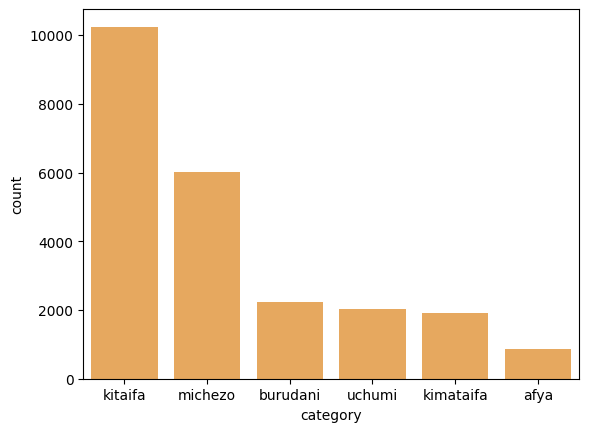

In [13]:
sns.countplot(
    x="category",
    data=swahili_news,
    color="#fdaa48",
    order=swahili_news["category"].value_counts().index
    )

<Axes: xlabel='category', ylabel='count'>

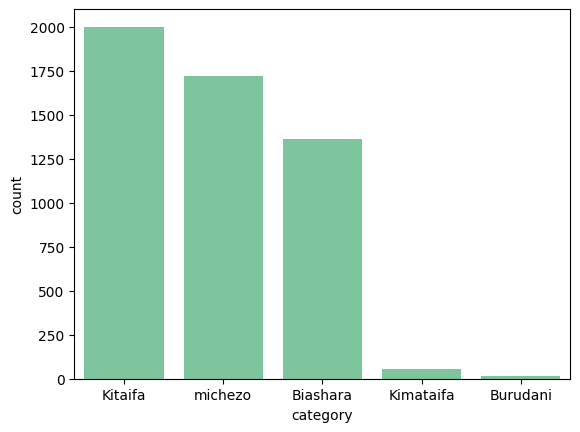

In [14]:
sns.countplot(
    x="category",
    data=holdout_train,
    color="#72d09c",
    order=holdout_train["category"].value_counts().index
    )

In [15]:
holdout_train[holdout_train["content"] == str(swahili_news.loc[1, "content"].lower().rstrip().lstrip())]

,id,content,category


In [16]:
swahili_news.loc[23258, "content"].lower().rstrip().lstrip()

'na ramadhan libenanga-morogoro \nwafugaji wilayani mvomero mkoa wa morogoro, wamesema wamekuwa wakitumia fedha nyingi kununua mihtasari ya vikao vya vijiji ili kuzionyesha mamlaka mbalimbali jinsi walivyoruhusiwa kumiliki ardhi waliyonayo.\nhayo yalielezwa jana na mchungaji joseph sepuke, alipokuwa akizungumza kwenye mkutano wa hadhara katika kijiji cha kibaoni wilayani mvomero. \n“wamasai wanapata mihtasari ya kijiji kwa gharama kubwa na viongozi hawa hawa wa vijiji ndio wanaowauzia hii mihtasari ili waweze kumilikishwa maeneo. \n“kwa hiyo, tunaomba gharama za mihtasari hiyo zipunguzwe ili tuweze kuzipata kwa urahisi zaidi,” alisema sepuke.\nawali, akizungumza katika mkutano huo, mjumbe wa serikali ya kijiji cha kibaoni, fabian beatus, alisema kijiji chao kimegundua kuna baadhi ya wananchi walioghushi mihtasari ya vijiji na kufanikiwa kupata ardhi. \n“kuna watu wameghushi mihtasari kwa sababu sharti kuu linalomwezesha mwananchi kumiliki ardhi ni kuwa na muhtasari unaoonyesha vikao ha

In [17]:
# set(holdout_train["id"].unique().tolist()) - set(swahili_news["id"].unique().tolist())

In [18]:
set(holdout_train["id"].unique().tolist()) & set(swahili_news["id"].unique().tolist())

{'SW981',
 'SW920',
 'SW2493',
 'SW2550',
 'SW444',
 'SW5021',
 'SW3159',
 'SW6374',
 'SW6021',
 'SW1222',
 'SW3003',
 'SW3074',
 'SW5960',
 'SW3590',
 'SW2423',
 'SW5070',
 'SW1529',
 'SW792',
 'SW1855',
 'SW6248',
 'SW846',
 'SW4655',
 'SW2497',
 'SW3767',
 'SW791',
 'SW6223',
 'SW2938',
 'SW4717',
 'SW413',
 'SW3109',
 'SW622',
 'SW5166',
 'SW5300',
 'SW1832',
 'SW763',
 'SW2070',
 'SW5218',
 'SW6106',
 'SW1419',
 'SW1316',
 'SW3',
 'SW4710',
 'SW375',
 'SW963',
 'SW279',
 'SW3928',
 'SW2005',
 'SW4976',
 'SW2368',
 'SW5216',
 'SW4260',
 'SW635',
 'SW4141',
 'SW5395',
 'SW1957',
 'SW3944',
 'SW1652',
 'SW2846',
 'SW2451',
 'SW212',
 'SW2977',
 'SW1226',
 'SW2627',
 'SW1296',
 'SW6371',
 'SW2746',
 'SW474',
 'SW1866',
 'SW2060',
 'SW2405',
 'SW2655',
 'SW5142',
 'SW339',
 'SW731',
 'SW1150',
 'SW1167',
 'SW2872',
 'SW4072',
 'SW4935',
 'SW5511',
 'SW2980',
 'SW1936',
 'SW5397',
 'SW3227',
 'SW46',
 'SW613',
 'SW4220',
 'SW4131',
 'SW3266',
 'SW601',
 'SW2277',
 'SW6076',
 'SW6050',
 

In [19]:
# swahili_news[swahili_news["id"].isin(list(set(holdout_train["id"].unique().tolist()) & set(swahili_news["id"].unique().tolist())))]

In [20]:
# holdout_train[holdout_train["id"].isin(list(set(holdout_train["id"].unique().tolist()) & set(swahili_news["id"].unique().tolist())))]

In [21]:
# merge the datasets
merged_swahili_news = pd.concat([swahili_news, holdout_train])

In [22]:
swahili_news.shape[0] + holdout_train.shape[0]

28419

In [23]:
# swahili_news[swahili_news["category"] == "kitaifa"].head()

In [24]:
holdout_train[holdout_train["category"] == "kitaifa"].head()

,id,content,category


In [25]:
[news for news in swahili_news["content"].tolist() if "serikali imesema haitakuwa" in news]

[]

In [26]:
merged_swahili_news[merged_swahili_news["content"].duplicated()]

id  \
40    SW29020   
50    SW13033   
142   SW29598   
211   SW24604   
262   SW23250   
...       ...   
5146    SW993   
5147    SW994   
5148    SW996   
5149    SW997   
5150    SW999   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [27]:
merged_swahili_news[~merged_swahili_news["content"].duplicated()]

,id,content,category
0,SW4670,"Bodi ya Utalii Tanzania (TTB) imesema, itafanya misafara ya kutangaza utalii kwenye miji minne nchini China kati ya Juni 19 hadi Juni 26 mwaka huu.Misafara hiyo itatembelea miji ya Beijing Juni 19, Shanghai Juni 21, Nanjig Juni 24 na Changsha Juni 26.Mwenyekiti wa bodi TTB, Jaji Mstaafu Thomas Mihayo ameyasema hayo kwenye mkutano na waandishi wa habari jijini Dar es Salaam.“Tunafanya jitihada kuhakikisha tunavuna watalii wengi zaidi kutoka China hasa tukizingatia umuhimu wa soko la sekta ya utalii nchini,” amesema Jaji Mihayo.Novemba 2018 TTB ilifanya ziara kwenye miji ya Beijing, Shanghai, Chengdu, Guangzhou na Hong Kong kutangaza vivutio vya utalii sanjari kuzitangaza safari za ndege za Air Tanzania.Ziara hiyo inaelezwa kuzaa matunda ikiwa ni pamoja na watalii zaidi ya 300 kuja nchini Mei mwaka huu kutembelea vivutio vya utalii.",uchumi
1,SW30826,"PENDO FUNDISHA-MBEYA RAIS Dk. John Magufuri, ametangaza kuwafukuza\nkazi wakurugenzi wote wa halmashauri ambao watabainika kukiuka sheria ya\nufutaji wa tozo za ushuru wa mazao. Alisema baada ya kuingia madarakani, Serikali\niliondoa tozo 80, miongoni mwa hizo tozo ushuru wakulima ambao walikuwa\nwakilipa mazao kutoka halmashauri moja kwenda nyingine. Rais Dk. Magufuli, aliyasema hayo juzi alipokuwa\nakiwahutubia wakazi wa Wilaya ya Kyela katika ziara ya kikazi ya siku 10 mkoani\nMbeya. Alisema, sheria ya ufutaji wa tozo hizo\nzilipitishwa na Bunge hivyo hakuna mtu yoyote wa kuitengua na kwamba Mkurugenzi\natakaye itengua atakuwa umevunja sheria na anawajibu wa kufukuzwa kazi. Alisema licha ya kupitishwa kwa sheria hiyo wapo\nbaadhi ya watendaji wameendelea kuwatoza ushuru wananchi kwa kisingizio cha\nkupandisha ukusanyaji wa mapato hilo jambo sitaki kulisikia. “Wapo watendaji\nwanasema kufutwa kwa ushuru kunapunguza mapato, narudia kwa viongozi wote, wakurugenzi,\nwatendaji wote wa halmashauri msiwatoze wananchi ushuru wa mzigo wowote usio\nzidi tani moja,”alisema. Hata hivyo, alitoa wito kwa watendaji kuzingatia\nsheria ya kuwalinda wakulima na ndio maana serikali iliziondoa tozo 80.",kitaifa
2,SW29725,"Mwandishi Wetu -Singida BENKI ya NMB imetoa msaada wa vifaa mbalimbali vyenye thamani ya zaidi ya Sh milioni 200 katika wilaya kadhaa nchini. Misaada iliyotolewa na benki hiyo inayoongoza kwa kutengeneza faida kati ya benki zote zinazofanya biashara humu nchini ndani ya miezi mitano mwaka huu, inahusisha vifaa vya ujenzi, madawati na vifaa vingine vinavyowezesha ukamilishaji wa miradi ya afya,elimu na usalama wa raia. Benki ya NMB imeshatoa msaada wa vifaa vyenye thamani ya zaidi ya Sh milioni 200 kwa mikoa ya Kanda ya Kati. Akifafanua kuhusu misaada hiyo wakati akikabidhi msaada wa madawati na vitanda kwa baadhi ya shule katika Halmashauri ya Wilaya ya Iramba mkoani ingida, Meneja wa Kanda ya Kati wa NMB, Nsolo Mlozi, alibainisha kuwa misaada hiyo ya zaidi ya Sh milioni 200 iliyotolewa imelenga sekta ya elimu, afya na majanga kwa mikoa mitatu ya Kanda ya kati. Akikabidhi msaada wa madawati na vitanda kwa baadhi ya shule za Halmashauri ya Wilaya ya Iramba, MkoaniSingida, katika shule ya Sekondari ya New Kiomboi, Mlozi alisema fedha hizo zilizotolewa na NMB zimetumika kununua madawati, viti vya shule za sekondari,vitanda na vifaa tiba kwenye sekta ya afya. Aidha, alisema lengo la misaada hiyo ni kuunga mkono juhudi za serikali kuwahudumia wananchi kwenye sekta mbalimbali. Pia alisema misaada hiyo imekabidhiwa kwa baadhi ya shule, zahanati, hospitali katika mikoa ya Singida, Dodoma na Manyara. Pia NMB walikabidhi madawati 250 na vitanda 80 vyenye thamani ya zaidi ya Sh milioni 29.5 kwa baadhi ya shule za Wilaya ya Iramba mkoani humo. Katika hatua nyingine, Benki hiyo imevipatia kituo cha Polisi Wilaya ya Kilosa mkoani Morogoro pamoja na shule ya msingi Msowelo mabati 160 yenye thamani ya Sh5 milioni kwa ajili ya kuezekea maboma. NMB iliamua kutoa msaada huo ikiwa ni mpango wa kuzipunguza baadhi ya changamoto kwa taasisi za serikali hapa nchini, Meneja 

In [28]:
4908 + 23511

28419

In [29]:
merged_swahili_news.shape

(28419, 3)

In [30]:
merged_swahili_news["category"].unique()

array(['uchumi', 'kitaifa', 'michezo', 'kimataifa', 'burudani', 'afya',
       'Kitaifa', 'Biashara', 'Kimataifa', 'Burudani'], dtype=object)

In [31]:
(merged_swahili_news[merged_swahili_news["content"].duplicated()].shape[0] / merged_swahili_news.shape[0]) * 100

17.270136176501634

In [32]:
merged_swahili_news[merged_swahili_news["content"].duplicated()].loc[0, "content"]

' SERIKALI imesema haitakuwa tayari kuona amani na utulivu wa nchi inachezewa huku ikisisitiza uwepo wa umoja kati ya wananchi bila kujali tofauti ya imani, kabila au itikadi yoyote.Hayo yalisemwa na Naibu Waziri wa Mambo ya Ndani ya Nchi, Hamad Yussuf Masauni wakati akifungua semina ya siku mbili iliyofanyika jijini Dar es Salaam ikiwahusisha viongozi wa taasisi za Kiislamu, lengo ikiwa ni kuwakumbusha kuhubiri amani katika sehemu zao.Naibu Waziri amesema mwelekeo na malengo ya Serikali ya Awamu ya Tano ni kukuza maendeleo katika sehemu mbalimbali nchini lengo ikiwa kuinua maisha ya wananchi na nchi kwa ujumla.“Serikali hii imejidhatiti kuhakikisha maendeleo yanakuja kwa kasi na maendeleo hayawezi kuja ikiwa amani na utulivu haupo, sisi kama serikali tutahakikisha tunalinda amani iliyopo ili wananchi wapate kufanya shughuli za kiuchumi bila wasiwasi wowote,” amesema Masauni.Akizungumza wakati wa ufunguzi huo, Shehe wa Mkoa wa Dar es Salaam, Alhaji Alhad Mussa Salum aliihakikishia seri

In [33]:
# merged_swahili_news[merged_swahili_news["content"] == "serikali imesema haitakuwa tayari kuona amani na utulivu wa nchi inachezewa huku ikisisitiza uwepo wa umoja kati ya wananchi bila kujali tofauti ya imani, kabila au itikadi yoyote.hayo yalisemwa na naibu waziri wa mambo ya ndani ya nchi, hamad yussuf masauni wakati akifungua semina ya siku mbili iliyofanyika jijini dar es salaam ikiwahusisha viongozi wa taasisi za kiislamu, lengo ikiwa ni kuwakumbusha kuhubiri amani katika sehemu zao.naibu waziri amesema mwelekeo na malengo ya serikali ya awamu ya tano ni kukuza maendeleo katika sehemu mbalimbali nchini lengo ikiwa kuinua maisha ya wananchi na nchi kwa ujumla.“serikali hii imejidhatiti kuhakikisha maendeleo yanakuja kwa kasi na maendeleo hayawezi kuja ikiwa amani na utulivu haupo, sisi kama serikali tutahakikisha tunalinda amani iliyopo ili wananchi wapate kufanya shughuli za kiuchumi bila wasiwasi wowote,” amesema masauni.akizungumza wakati wa ufunguzi huo, shehe wa mkoa wa dar es salaam, alhaji alhad mussa salum aliihakikishia serikali kutokuwepo kwa mifarakano kati ya taasisi mbalimbali kama ilivyokuwepo awali huku akisisitiza kuendelea kwa umoja huo ili jamii ipate kuendelea.“sisi kama bakwata tunaihakikishia serikali uwepo wa umoja na ushirikiano baina ya baraza na taasisi zingine na tofauti zetu hazipelekei kukoseana au kuvunjiana heshima kwahiyo tunaomba serikali iamini uwepo wa maelewano mazuri tu kwa maendeleo ya nchi hii,” amesema shehe alhad.semina hiyo ya siku mbili imejumuisha viongozi wa taasisi 100 huku mada ya nafasi ya taasisi za kiislamu katika kuleta umoja na kuishi kwa amani itajadiliwa."]

In [34]:
# tokenizer = AutoTokenizer.from_pretrained("Benjamin-png/bert-tokenizer-swahili")

# model = AutoModelForTokenClassification.from_pretrained("castorini/afriberta_base")
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
# tokenizer.model_max_length = 512


In [35]:
# tokenizer.tokenize(merged_swahili_news[merged_swahili_news["content"] == "serikali imesema haitakuwa tayari kuona amani na utulivu wa nchi inachezewa huku ikisisitiza uwepo wa umoja kati ya wananchi bila kujali tofauti ya imani, kabila au itikadi yoyote.hayo yalisemwa na naibu waziri wa mambo ya ndani ya nchi, hamad yussuf masauni wakati akifungua semina ya siku mbili iliyofanyika jijini dar es salaam ikiwahusisha viongozi wa taasisi za kiislamu, lengo ikiwa ni kuwakumbusha kuhubiri amani katika sehemu zao.naibu waziri amesema mwelekeo na malengo ya serikali ya awamu ya tano ni kukuza maendeleo katika sehemu mbalimbali nchini lengo ikiwa kuinua maisha ya wananchi na nchi kwa ujumla.“serikali hii imejidhatiti kuhakikisha maendeleo yanakuja kwa kasi na maendeleo hayawezi kuja ikiwa amani na utulivu haupo, sisi kama serikali tutahakikisha tunalinda amani iliyopo ili wananchi wapate kufanya shughuli za kiuchumi bila wasiwasi wowote,” amesema masauni.akizungumza wakati wa ufunguzi huo, shehe wa mkoa wa dar es salaam, alhaji alhad mussa salum aliihakikishia serikali kutokuwepo kwa mifarakano kati ya taasisi mbalimbali kama ilivyokuwepo awali huku akisisitiza kuendelea kwa umoja huo ili jamii ipate kuendelea.“sisi kama bakwata tunaihakikishia serikali uwepo wa umoja na ushirikiano baina ya baraza na taasisi zingine na tofauti zetu hazipelekei kukoseana au kuvunjiana heshima kwahiyo tunaomba serikali iamini uwepo wa maelewano mazuri tu kwa maendeleo ya nchi hii,” amesema shehe alhad.semina hiyo ya siku mbili imejumuisha viongozi wa taasisi 100 huku mada ya nafasi ya taasisi za kiislamu katika kuleta umoja na kuishi kwa amani itajadiliwa."]["content"])

In [36]:
def text_preprocessing(text):
    text = text.lower().rstrip().lstrip()
    return re.sub(r'[.,]', '', text)

merged_swahili_news["content"] = merged_swahili_news["content"].apply(lambda x: text_preprocessing(x))
merged_swahili_news.head(1)

,id,content,category
0,SW4670,bodi ya utalii tanzania (ttb) imesema itafanya misafara ya kutangaza utalii kwenye miji minne nchini china kati ya juni 19 hadi juni 26 mwaka huumisafara hiyo itatembelea miji ya beijing juni 19 shanghai juni 21 nanjig juni 24 na changsha juni 26mwenyekiti wa bodi ttb jaji mstaafu thomas mihayo ameyasema hayo kwenye mkutano na waandishi wa habari jijini dar es salaam“tunafanya jitihada kuhakikisha tunavuna watalii wengi zaidi kutoka china hasa tukizingatia umuhimu wa soko la sekta ya utalii nchini” amesema jaji mihayonovemba 2018 ttb ilifanya ziara kwenye miji ya beijing shanghai chengdu guangzhou na hong kong kutangaza vivutio vya utalii sanjari kuzitangaza safari za ndege za air tanzaniaziara hiyo inaelezwa kuzaa matunda ikiwa ni pamoja na watalii zaidi ya 300 kuja nchini mei mwaka huu kutembelea vivutio vya utalii,uchumi


In [37]:
merged_swahili_news.tail(1)

,id,content,category
5150,SW999,akizungumza mara baada ya kutiwa saini kwa makubaliano hayo jana jioni waziri wa nchi ofisi ya waziri mkuu tawala za mikoa na serikali za mitaa hawa ghasia alisema uwekezaji huo unatarajiwa kuleta manufaa kwa shirika hilo kwani uwekezaji wake pia utasaidia kutoa elimu kwa vitendo juu ya ufugaji kwa kada mbalimbalialisema miaka ya nyuma shirika hilo lilikuwa likisifika kwa ufugaji wa kuku kabla ya kusitisha shughuli hizo kutokana na uwepo wa sababu mbalimbali na kusababisha shirika hilo kukosa mapato yaliyokuwa yakitokana na uuzaji wa kuku na mayaimkurugenzi wa shirika la elimu kibaha cyprian mpemba alisema uwekezaji huo wa miaka 66 mbali na kuingizia shirika hilo kiasi cha sh milioni 100 kila mwaka pia utawawezesha kuvuna kiasi kingine kama hicho kama ada ya uingiaji katika eneo hiloalisema itachukua muda wa miaka nane hadi uwekezaji rasmi ukamilike katika eneo hilo ukihusisha idara mbalimbali ikiwemo ujenzi wa viwanda vya usindikaji wa nyama na utengenezaji wa soseji huku kila baada ya miaka miwili wakikamilisha ujenzi wa eneo yakiwemo maeneo ya kufugia kuku haompemba alisema matarajio baada ya mika miwili ijayo mradi huo utaweza kuzalisha kuku milioni 27 huku wakitoa ajira kwa watu 120 na ukikamilika utazalisha kuku milioni 165 pamoja na kutoa ajira kwa watu 700 hatua aliyosema itasaidia kuleta mapinduzi katika ufugaji wa kuku hapa nchini sambamba na kutoa elimu kwa wanafunzi kutoka vyuo mbalimbalinaye mtendaji mkuu wa kampuni hiyo hesham ewies alisema malengo yao ni kuibadilisha kibaha kwa muda mfupi kwa kulifanya kuwa eneo linalosifika kutokana na shughuli za ufugaji wa kuku huku zaidi wakilenga kuondoa upungufu wa mahitaji ya bidhaa ya kuku yaliyopo kwa sasa nchinialisema watarajio yao baada ya miaka michache ijayo tanzania itaweza kusifika kwa usafirishaji wa bidhaa zitokanazo na kuku kwenda nje ya nchi na hivyo kuliongeza taifa mapato,Biashara


In [ ]:
def tokenize(text):
    tokens = tokenizer.tokenize(text)
    encoding = tokenizer(
                    text,
                    max_length=512,
                    truncation=True,
                    stride=128,
                    return_overflowing_tokens=True,
                    padding="max_length"
                    )
    token_ids = encoding["input_ids"]
    return tokens, token_ids

merged_swahili_news["tokenized"] = merged_swahili_news["content"].apply(lambda x: tokenize(x)[0])
merged_swahili_news["token_ids"] = merged_swahili_news["content"].apply(lambda x: tokenize(x)[1])

In [ ]:
merged_swahili_news.head(2)

In [39]:
merged_swahili_news.head(2)

,id,content,category,tokenized,token_ids
0,SW4670,bodi ya utalii tanzania (ttb) imesema itafanya misafara ya kutangaza utalii kwenye miji minne nchini china kati ya juni 19 hadi juni 26 mwaka huumisafara hiyo itatembelea miji ya beijing juni 19 shanghai juni 21 nanjig juni 24 na changsha juni 26mwenyekiti wa bodi ttb jaji mstaafu thomas mihayo ameyasema hayo kwenye mkutano na waandishi wa habari jijini dar es salaam“tunafanya jitihada kuhakikisha tunavuna watalii wengi zaidi kutoka china hasa tukizingatia umuhimu wa soko la sekta ya utalii nchini” amesema jaji mihayonovemba 2018 ttb ilifanya ziara kwenye miji ya beijing shanghai chengdu guangzhou na hong kong kutangaza vivutio vya utalii sanjari kuzitangaza safari za ndege za air tanzaniaziara hiyo inaelezwa kuzaa matunda ikiwa ni pamoja na watalii zaidi ya 300 kuja nchini mei mwaka huu kutembelea vivutio vya utalii,uchumi,"[▁bod, i, ▁ya, ▁utal, ii, ▁tan, zania, ▁(, tt, b, ), ▁i, mesema, ▁ita, fanya, ▁mis, a, fara, ▁ya, ▁ku, tangaza, ▁utal, ii, ▁kwenye, ▁mij, i, ▁minne, ▁nchini, ▁, china, ▁kati, ▁ya, ▁juni, ▁19, ▁hadi, ▁juni, ▁26, ▁mwaka, ▁huu, mis, a, fara, ▁hiyo, ▁ita, tembelea, ▁mij, i, ▁ya, ▁bei, jing, ▁juni, ▁19, ▁s, hang, hai, ▁juni, ▁21, ▁na, nji, g, ▁juni, ▁24, ▁na, ▁, chang, sha, ▁juni, ▁26, m, wen, yek, iti, ▁wa, ▁bod, i, ▁, tt, b, ▁ja, ji, ▁m, staafu, ▁tho, mas, ▁mi, hay, o, ▁ame, y, asema, ▁hayo, ▁kwenye, ▁mkutano, ▁na, ▁waandishi, ▁wa, ▁habari, ▁jijini, ▁dar, ▁es, ...]","[0, 4486, 14, 151, 69243, 1573, 2197, 45725, 15, 3062, 275, 16, 17, 87035, 20973, 18357, 1239, 11, 64087, 151, 228, 51666, 69243, 1573, 5538, 10826, 14, 53807, 10790, 6, 42072, 23210, 151, 13645, 953, 24205, 13645, 1381, 9353, 11877, 2179, 11, 64087, 5748, 20973, 96341, 10826, 14, 151, 1079, 91577, 13645, 953, 91, 8467, 15251, 13645, 952, 24, 6942, 177, 13645, 744, 24, 6, 90965, 2420, 13645, 1381, 39, 11697, 21998, 1890, 259, 4486, 14, 6, 3062, 275, 79, 658, 347, 129637, 14461, 1510, 324, 12862, 31, 13721, 53, 52660, 19562, 5538, 52041, 24, 94525, 259, 17508, 36345, 1011, ...]"
1,SW30826,pendo fundisha-mbeya rais dk john magufuri ametangaza kuwafukuza\nkazi wakurugenzi wote wa halmashauri ambao watabainika kukiuka sheria ya\nufutaji wa tozo za ushuru wa mazao alisema baada ya kuingia madarakani serikali\niliondoa tozo 80 miongoni mwa hizo tozo ushuru wakulima ambao walikuwa\nwakilipa mazao kutoka halmashauri moja kwenda nyingine rais dk magufuli aliyasema hayo juzi alipokuwa\nakiwahutubia wakazi wa wilaya ya kyela katika ziara ya kikazi ya siku 10 mkoani\nmbeya alisema sheria ya ufutaji wa tozo hizo\nzilipitishwa na bunge hivyo hakuna mtu yoyote wa kuitengua na kwamba mkurugenzi\natakaye itengua atakuwa umevunja sheria na anawajibu wa kufukuzwa kazi alisema licha ya kupitishwa kwa sheria hiyo wapo\nbaadhi ya watendaji wameendelea kuwatoza ushuru wananchi kwa kisingizio cha\nkupandisha ukusanyaji wa mapato hilo jambo sitaki kulisikia “wapo watendaji\nwanasema kufutwa kwa ushuru kunapunguza mapato narudia kwa viongozi wote wakurugenzi\nwatendaji wote wa halmashauri msiwatoze wananchi ushuru wa mzigo wowote usio\nzidi tani moja”alisema hata hivyo alitoa wito kwa watendaji kuzingatia\nsheria ya kuwalinda wakulima na ndio maana serikali iliziondoa tozo 80,kitaifa,"[▁pe, ndo, ▁, fundisha, -, mbe, ya, ▁rais, ▁dk, ▁joh, n, ▁mag, u, furi, ▁ame, tangaza, ▁kuwa, fu, ku, za, ▁kazi, ▁wa, kurugenzi, ▁wote, ▁wa, ▁halmashauri, ▁ambao, ▁wata, baini, ka, ▁kuki, uka, ▁sheria, ▁ya, ▁u, fut, aji, ▁wa, ▁to, zo, ▁za, ▁us, hur, u, ▁wa, ▁maza, o, ▁alisema, ▁baada, ▁ya, ▁kuingia, ▁mada, rakan, i, ▁serikali, ▁ili, ondo, a, ▁to, zo, ▁80, ▁miongon, i, ▁mwa, ▁hizo, ▁to, zo, ▁us, hur, u, ▁wakulima, ▁ambao, ▁walikuwa, ▁waki, lipa, ▁maza, o, ▁kutoka, ▁halmashauri, ▁moja, ▁kwenda, ▁nyingine, ▁rais, ▁dk, ▁mag, ufu, li, ▁ali, y, asema, ▁hayo, ▁ju, zi, ▁a, lipokuwa, ▁akiwa, hutubia, ▁wakazi, ▁wa, ▁wilaya, ...]","[0, 280, 557, 6, 204966, 9, 20439, 395, 40129, 126920, 35254, 19, 1697, 34, 157391, 13721, 51666, 1922, 3125, 319, 596, 134

In [40]:
# merged_swahili_news[merged_swahili_news["content"] == "serikali imesema haitakuwa tayari kuona amani na utulivu wa nchi inachezewa huku ikisisitiza uwepo wa umoja kati ya wananchi bila kujali tofauti ya imani, kabila au itikadi yoyote.hayo yalisemwa na naibu waziri wa mambo ya ndani ya nchi, hamad yussuf masauni wakati akifungua semina ya siku mbili iliyofanyika jijini dar es salaam ikiwahusisha viongozi wa taasisi za kiislamu, lengo ikiwa ni kuwakumbusha kuhubiri amani katika sehemu zao.naibu waziri amesema mwelekeo na malengo ya serikali ya awamu ya tano ni kukuza maendeleo katika sehemu mbalimbali nchini lengo ikiwa kuinua maisha ya wananchi na nchi kwa ujumla.“serikali hii imejidhatiti kuhakikisha maendeleo yanakuja kwa kasi na maendeleo hayawezi kuja ikiwa amani na utulivu haupo, sisi kama serikali tutahakikisha tunalinda amani iliyopo ili wananchi wapate kufanya shughuli za kiuchumi bila wasiwasi wowote,” amesema masauni.akizungumza wakati wa ufunguzi huo, shehe wa mkoa wa dar es salaam, alhaji alhad mussa salum aliihakikishia serikali kutokuwepo kwa mifarakano kati ya taasisi mbalimbali kama ilivyokuwepo awali huku akisisitiza kuendelea kwa umoja huo ili jamii ipate kuendelea.“sisi kama bakwata tunaihakikishia serikali uwepo wa umoja na ushirikiano baina ya baraza na taasisi zingine na tofauti zetu hazipelekei kukoseana au kuvunjiana heshima kwahiyo tunaomba serikali iamini uwepo wa maelewano mazuri tu kwa maendeleo ya nchi hii,” amesema shehe alhad.semina hiyo ya siku mbili imejumuisha viongozi wa taasisi 100 huku mada ya nafasi ya taasisi za kiislamu katika kuleta umoja na kuishi kwa amani itajadiliwa."]

In [41]:
# merged_swahili_news.loc[5493, "tokenized"]

In [42]:
merged_swahili_news.head(1)

,id,content,category,tokenized,token_ids
0,SW4670,bodi ya utalii tanzania (ttb) imesema itafanya misafara ya kutangaza utalii kwenye miji minne nchini china kati ya juni 19 hadi juni 26 mwaka huumisafara hiyo itatembelea miji ya beijing juni 19 shanghai juni 21 nanjig juni 24 na changsha juni 26mwenyekiti wa bodi ttb jaji mstaafu thomas mihayo ameyasema hayo kwenye mkutano na waandishi wa habari jijini dar es salaam“tunafanya jitihada kuhakikisha tunavuna watalii wengi zaidi kutoka china hasa tukizingatia umuhimu wa soko la sekta ya utalii nchini” amesema jaji mihayonovemba 2018 ttb ilifanya ziara kwenye miji ya beijing shanghai chengdu guangzhou na hong kong kutangaza vivutio vya utalii sanjari kuzitangaza safari za ndege za air tanzaniaziara hiyo inaelezwa kuzaa matunda ikiwa ni pamoja na watalii zaidi ya 300 kuja nchini mei mwaka huu kutembelea vivutio vya utalii,uchumi,"[▁bod, i, ▁ya, ▁utal, ii, ▁tan, zania, ▁(, tt, b, ), ▁i, mesema, ▁ita, fanya, ▁mis, a, fara, ▁ya, ▁ku, tangaza, ▁utal, ii, ▁kwenye, ▁mij, i, ▁minne, ▁nchini, ▁, china, ▁kati, ▁ya, ▁juni, ▁19, ▁hadi, ▁juni, ▁26, ▁mwaka, ▁huu, mis, a, fara, ▁hiyo, ▁ita, tembelea, ▁mij, i, ▁ya, ▁bei, jing, ▁juni, ▁19, ▁s, hang, hai, ▁juni, ▁21, ▁na, nji, g, ▁juni, ▁24, ▁na, ▁, chang, sha, ▁juni, ▁26, m, wen, yek, iti, ▁wa, ▁bod, i, ▁, tt, b, ▁ja, ji, ▁m, staafu, ▁tho, mas, ▁mi, hay, o, ▁ame, y, asema, ▁hayo, ▁kwenye, ▁mkutano, ▁na, ▁waandishi, ▁wa, ▁habari, ▁jijini, ▁dar, ▁es, ...]","[0, 4486, 14, 151, 69243, 1573, 2197, 45725, 15, 3062, 275, 16, 17, 87035, 20973, 18357, 1239, 11, 64087, 151, 228, 51666, 69243, 1573, 5538, 10826, 14, 53807, 10790, 6, 42072, 23210, 151, 13645, 953, 24205, 13645, 1381, 9353, 11877, 2179, 11, 64087, 5748, 20973, 96341, 10826, 14, 151, 1079, 91577, 13645, 953, 91, 8467, 15251, 13645, 952, 24, 6942, 177, 13645, 744, 24, 6, 90965, 2420, 13645, 1381, 39, 11697, 21998, 1890, 259, 4486, 14, 6, 3062, 275, 79, 658, 347, 129637, 14461, 1510, 324, 12862, 31, 13721, 53, 52660, 19562, 5538, 52041, 24, 94525, 259, 17508, 36345, 1011, ...]"


In [ ]:
merged_swahili_news["token_length"] = merged_swahili_news["tokenized"].apply(lambda x: len(x))

,id,content,category,tokenized,token_ids,token_length
0,SW4670,bodi ya utalii tanzania (ttb) imesema itafanya misafara ya kutangaza utalii kwenye miji minne nchini china kati ya juni 19 hadi juni 26 mwaka huumisafara hiyo itatembelea miji ya beijing juni 19 shanghai juni 21 nanjig juni 24 na changsha juni 26mwenyekiti wa bodi ttb jaji mstaafu thomas mihayo ameyasema hayo kwenye mkutano na waandishi wa habari jijini dar es salaam“tunafanya jitihada kuhakikisha tunavuna watalii wengi zaidi kutoka china hasa tukizingatia umuhimu wa soko la sekta ya utalii nchini” amesema jaji mihayonovemba 2018 ttb ilifanya ziara kwenye miji ya beijing shanghai chengdu guangzhou na hong kong kutangaza vivutio vya utalii sanjari kuzitangaza safari za ndege za air tanzaniaziara hiyo inaelezwa kuzaa matunda ikiwa ni pamoja na watalii zaidi ya 300 kuja nchini mei mwaka huu kutembelea vivutio vya utalii,uchumi,"[▁bod, i, ▁ya, ▁utal, ii, ▁tan, zania, ▁(, tt, b, ), ▁i, mesema, ▁ita, fanya, ▁mis, a, fara, ▁ya, ▁ku, tangaza, ▁utal, ii, ▁kwenye, ▁mij, i, ▁minne, ▁nchini, ▁, china, ▁kati, ▁ya, ▁juni, ▁19, ▁hadi, ▁juni, ▁26, ▁mwaka, ▁huu, mis, a, fara, ▁hiyo, ▁ita, tembelea, ▁mij, i, ▁ya, ▁bei, jing, ▁juni, ▁19, ▁s, hang, hai, ▁juni, ▁21, ▁na, nji, g, ▁juni, ▁24, ▁na, ▁, chang, sha, ▁juni, ▁26, m, wen, yek, iti, ▁wa, ▁bod, i, ▁, tt, b, ▁ja, ji, ▁m, staafu, ▁tho, mas, ▁mi, hay, o, ▁ame, y, asema, ▁hayo, ▁kwenye, ▁mkutano, ▁na, ▁waandishi, ▁wa, ▁habari, ▁jijini, ▁dar, ▁es, ...]","[0, 4486, 14, 151, 69243, 1573, 2197, 45725, 15, 3062, 275, 16, 17, 87035, 20973, 18357, 1239, 11, 64087, 151, 228, 51666, 69243, 1573, 5538, 10826, 14, 53807, 10790, 6, 42072, 23210, 151, 13645, 953, 24205, 13645, 1381, 9353, 11877, 2179, 11, 64087, 5748, 20973, 96341, 10826, 14, 151, 1079, 91577, 13645, 953, 91, 8467, 15251, 13645, 952, 24, 6942, 177, 13645, 744, 24, 6, 90965, 2420, 13645, 1381, 39, 11697, 21998, 1890, 259, 4486, 14, 6, 3062, 275, 79, 658, 347, 129637, 14461, 1510, 324, 12862, 31, 13721, 53, 52660, 19562, 5538, 52041, 24, 94525, 259, 17508, 36345, 1011, ...]",218
1,SW30826,pendo fundisha-mbeya rais dk john magufuri ametangaza kuwafukuza\nkazi wakurugenzi wote wa halmashauri ambao watabainika kukiuka sheria ya\nufutaji wa tozo za ushuru wa mazao alisema baada ya kuingia madarakani serikali\niliondoa tozo 80 miongoni mwa hizo tozo ushuru wakulima ambao walikuwa\nwakilipa mazao kutoka halmashauri moja kwenda nyingine rais dk magufuli aliyasema hayo juzi alipokuwa\nakiwahutubia wakazi wa wilaya ya kyela katika ziara ya kikazi ya siku 10 mkoani\nmbeya alisema sheria ya ufutaji wa tozo hizo\nzilipitishwa na bunge hivyo hakuna mtu yoyote wa kuitengua na kwamba mkurugenzi\natakaye itengua atakuwa umevunja sheria na anawajibu wa kufukuzwa kazi alisema licha ya kupitishwa kwa sheria hiyo wapo\nbaadhi ya watendaji wameendelea kuwatoza ushuru wananchi kwa kisingizio cha\nkupandisha ukusanyaji wa mapato hilo jambo sitaki kulisikia “wapo watendaji\nwanasema kufutwa kwa ushuru kunapunguza mapato narudia kwa viongozi wote wakurugenzi\nwatendaji wote wa halmashauri msiwatoze wananchi ushuru wa mzigo wowote usio\nzidi tani moja”alisema hata hivyo alitoa wito kwa watendaji kuzingatia\nsheria ya kuwalinda wakulima na ndio maana serikali iliziondoa tozo 80,kitaifa,"[▁pe, ndo, ▁, fundisha, -, mbe, ya, ▁rais, ▁dk, ▁joh, n, ▁mag, u, furi, ▁ame, tangaza, ▁kuwa, fu, ku, za, ▁kazi, ▁wa, kurugenzi, ▁wote, ▁wa, ▁halmashauri, ▁ambao, ▁wata, baini, ka, ▁kuki, uka, ▁sheria, ▁ya, ▁u, fut, aji, ▁wa, ▁to, zo, ▁za, ▁us, hur, u, ▁wa, ▁maza, o, ▁alisema, ▁baada, ▁ya, ▁kuingia, ▁mada, rakan, i, ▁serikali, ▁ili, ondo, a, ▁to, zo, ▁80, ▁miongon, i, ▁mwa, ▁hizo, ▁to, zo, ▁us, hur, u, ▁wakulima, ▁ambao, ▁walikuwa, ▁waki, lipa, ▁maza, o, ▁kutoka, ▁halmashauri, ▁moja, ▁kwenda, ▁nyingine, ▁rais, ▁dk, ▁mag, ufu, li, ▁ali, y, asema, ▁hayo, ▁ju, zi, ▁a, lipokuwa, ▁akiwa, hutubia, ▁wakazi, ▁wa, ▁wilaya, ...]","[0, 280, 557, 6, 204966, 9, 20439, 395, 40129, 126920, 35254, 19, 1697, 34, 157391, 13721, 51666, 1922, 31

In [48]:
merged_swahili_news[["token_length"]].sort_values(by="token_length", ascending=False)

,token_length
9138,6823
4504,5935
4820,4025
15255,4009
617,4009
...,...
4906,3
19836,3
2861,0
13247,0


In [58]:
print(f"{round(merged_swahili_news[merged_swahili_news["token_length"] > 512].shape[0]/merged_swahili_news.shape[0] * 100, 2)}% of data has more than 512 tokens while {round(merged_swahili_news[merged_swahili_news["token_length"] <= 512].shape[0]/merged_swahili_news.shape[0] * 100, 2)}% has less than 512 tokens.")

34.93% of data has more than 512 tokens while 65.07% has less than 512 tokens.


In [56]:
merged_swahili_news[merged_swahili_news["token_length"] > 512].shape[0]/merged_swahili_news.shape[0] * 100

34.930856117386256

In [62]:
merged_swahili_news[merged_swahili_news["id"].isin(merged_swahili_news[merged_swahili_news["token_length"] > 512]["id"].unique().tolist())].head(1)

,id,content,category,tokenized,token_ids,token_length
4,SW12560,na agatha charles – dar es salaam aliyekuwa katibu wa bunge na serikali za mitaa katika sekretarieti ya chama cha act-wazalendo habibu mchange amejiondoa uanachama wa chama hicho na kujiweka kando na siasa taarifa ya uamuzi huo wa mchange ilisambazwa jana katika mitandao ya kijamii ikionyesha kuandikwa naye huku ikiambatanishwa na namba yake ya simu katika andiko hilo mchange aliyewahi kuwa mwanachama wa chadema kabla hajahamia act wazalendo alisema aliamua kujitoa rasmi katika ushiriki wa aina yoyote ya siasa ili apate muda zaidi wa kusimamia shughuli zake za kijasiriamali mchange alisema ameamua kujiengua na siasa ili kutoa fursa na huduma sawa kwa viongozi na wanachama wa vyama vyote vya siasa “kwa moyo mkunjufu kabisa na kwa mapenzi mema na taifa langu ninathibitisha kwamba nimejitoa rasmi katika ushiriki wa aina yote ya siasa ili nipate muda mwingi zaidi kufanya na kusimamia shughuli zangu za kijasiriamali zinazonitaka nitoe fursa na huduma sawa kwa viongozi na wanachama wa vyama vyote vya siasa” alisema mchange alisema kutokana na uamuzi huo ambao aliomba uheshimiwe lolote atakalolifanya lisihusishwe na chama bali iwe ni msimamo wake mwenyewe kama mtu huru asiye na chama “ninafahamu kuwa mwanachama wa chama cha siasa ni haki yangu ya kikatiba lakini nimeamua kuihifadhi kwa sasa mpaka hapo nitakapoona inafaa kufanya vinginevyo ninawatakia kila la heri waliokuwa wanachama wenzangu wa act wazalendo katika kuyafikia malengo ya msingi ya uanzishwaji wa chama hicho” alisema mchange mchange alisema kujiondoa kwake kusihesabiwe kama sehemu ya kukwamisha au kurudisha nyuma matarajio na au malengo ya chama hicho bali ichukuliwe kama chachu ya kufika mbali “msivunjike moyo msirumbane pendaneni heshimianeni na shikamaneni ili mfikie lengo nitabaki na kuendelea kuwa ndugu yenu rafiki na swahiba zaidi mtanzania mwenzenu tutaendelea kushirikiana katika mambo yote ya kijamii na kimaisha yasiyohusiana na mlengo wa kiitikadi wa kisiasa” alisema mchange mchange alishika nafasi mbalimbali katika chama hicho ikiwamo katibu wa mipango na mikakati mjumbe wa kamati kuu mjumbe wa halmashauri kuu na mjumbe wa mkutano mkuu mtanzania jumapili lilimtafuta mchange kwa simu kuthibitisha andiko hilo lakini hakuweza kupatikana alipotafutwa ofisa habari wa act-wazalendo abdallah khamis alikiri andiko hilo kuwa ni la mchange mchange anakuwa mwanasiasa wa tatu kuondoka act-wazalendo mwaka huu baada ya aliyekuwa katibu mkuu wa chama hicho samson mwigamba kuachia nafasi yake na kwenda masomoni nchini kenya aprili mwaka huu miezi michache baadaye novemba mwaka huu mwanasiasa moses machali naye alitangaza kujiondoa rasmi chama hicho na kuunga mkono jitihada zinazofanywa na rais dk john magufuli machali aliwahi kuwa mbunge wa kasulu mjini kupitia chama cha nccr-mageuzi kabla ya mwaka jana kushindwa kutetea jimbo lake kupitia act-wazalendo,kitaifa,"[▁na, ▁aga, tha, ▁char, les, ▁–, ▁dar, ▁es, ▁salaam, ▁aliyekuwa, ▁kati, bu, ▁wa, ▁bunge, ▁na, ▁serikali, ▁za, ▁mi, taa, ▁katika, ▁sekretari, eti, ▁ya, ▁chama, ▁cha, ▁act, -, wa, zale, ndo, ▁hab, ibu, ▁mchang, e, ▁ame, ji, ondo, a, ▁u, an, ach, ama, ▁wa, ▁chama, ▁hicho, ▁na, ▁kuji, weka, ▁kan, do, ▁na, ▁siasa, ▁taarifa, ▁ya, ▁uamuzi, ▁huo, ▁wa, ▁mchang, e, ▁ili, samba, zwa, ▁jana, ▁katika, ▁mitandao, ▁ya, ▁kijamii, ▁iki, onyesha, ▁ku, andikwa, ▁naye, ▁huku, ▁iki, am, batan, ishwa, ▁na, ▁namba, ▁yake, ▁ya, ▁simu, ▁katika, ▁and, iko, ▁hilo, ▁mchang, e, ▁aliye, wahi, ▁kuwa, ▁mwana, cha, ma, ▁wa, ▁cha, de, ma, ▁kabla, ▁haja, ...]","[0, 24, 5575, 3238, 21441, 1577, 46, 1011, 198, 96867, 142636, 23210, 978, 259, 121582, 24, 23317, 80, 324, 6803, 1622, 110836, 7207, 151, 19965, 1608, 27992, 9, 634, 61999, 557, 11598, 25708, 146904, 13, 13721, 658, 39413, 11, 75, 66, 934, 2887, 259, 19965, 39385, 24, 23639, 63766, 203, 246, 24, 93226, 34876, 151, 161555, 7126, 259, 146904, 13, 1499, 95347, 12781, 30938, 1622, 162587, 151, 125532, 2209, 63740, 228, 210832, 100193, 